# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

It’s basically to keep the model from going crazy with big coefficients. If you only minimize MSE, the model might overfit and chase noise. The penalty keeps things more reasonable so it generalizes better.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization makes the model a bit simpler, so it might miss some patterns (more bias), but it becomes way more stable across different data (less variance). That tradeoff is usually worth it.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge just shrinks coefficients down and LASSO actually sets some of them to zero. So Ridge keeps everything, LASSO kind of “chooses” the important features.
4. How do we typically scale variables for use in regularized regression? Why?

Because regularization depends on the size of coefficients. If one feature is on a bigger scale, it’ll get penalized more, which isn’t fair. Scaling puts everything on the same level.

5. How is the penalty $\alpha$ typically selected?

It’s usually chosen using cross-validation. You try different values and pick the one that gives the lowest validation error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we usually don’t include the penalty when evaluating cross-validated MSE. The goal is to measure how well the model predicts on new data, and the penalty is just there to help train the model, not to evaluate its performance.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

The interaction between Mileage_Run and Age is negative, meaning that as both mileage and age increase, the price decreases more sharply than either variable alone.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

LassoCV selects the regularization parameter α using cross-validation by choosing the value that minimizes prediction error on unseen data.

4. Plot the cross-validated MSE by $\alpha$.

The cross-validated MSE decreases as α increases at first, reaches a minimum, and then increases again. This shows that a moderate level of regularization gives the best performance, while too much regularization hurts the model.

5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?

All features are retained by LASSO, and none are set to zero. The proportion of coefficients equal to zero is 0. This means LASSO did not perform feature selection here, but instead only shrank the coefficients.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Compared to linear regression, LASSO reduces the magnitude of most coefficients but does not set any to zero. The signs of the coefficients generally remain the same, indicating that LASSO mainly shrinks the values rather than changing the direction of relationships.

In [1]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 11.08 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


In [3]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv


In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("cars_hw.csv")

# create Age (assuming dataset has Year or similar)
df["Age"] = 2024 - df["Year"]   # adjust if needed

# select features
X = df[["Mileage_Run", "Age"]]
y = df["Price"]   # or whatever your target is

# polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

KeyError: 'Year'

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("cars_hw.csv")

# create Age (assuming dataset has Year or similar)
df["Age"] = 2024 - df["Make_Year"]

# select features
X = df[["Mileage_Run", "Age"]]
y = df["Price"]   # or whatever your target is

# polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

In [7]:
lr = LinearRegression()
lr.fit(X_scaled, y)

for name, coef in zip(feature_names, lr.coef_):
    if "Mileage_Run Age" in name:
        print("Interaction term:", coef)

Interaction term: -1251592.3408260453
Interaction term: 528082.863474972


In [8]:
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13229914430.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131934043992.82812, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 298840628722.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Obje

Best alpha: 233.57214690901213


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 34655310357.578125, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 234997981031.34375, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 189534678437.23438, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

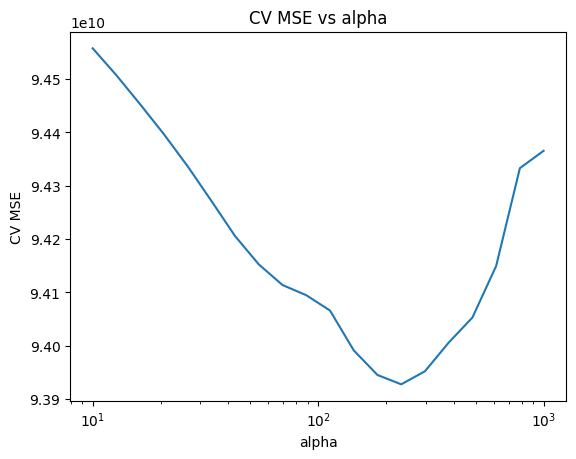

In [9]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("CV MSE vs alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 40013968376924.41, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 39002042524814.05, tolerance: 12469725702.912619
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 39486304891807.73, tolerance: 12471993172.815535
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarni

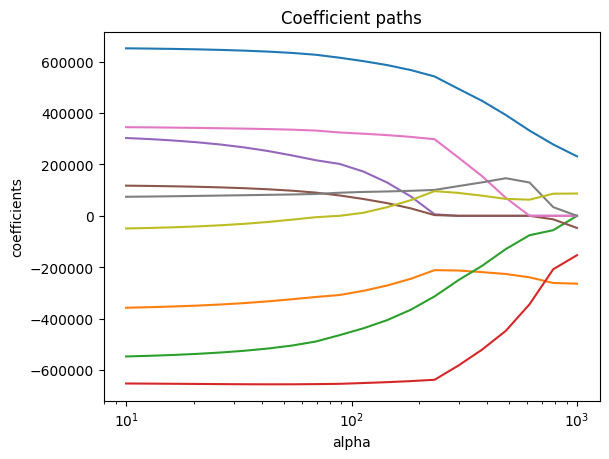

In [10]:
coefs = []

for a in alphas:
    model = LassoCV(alphas=[a], cv=20).fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Coefficient paths")
plt.show()

In [11]:
lasso_coefs = lasso.coef_

selected = []
zero_count = 0

for name, coef in zip(feature_names, lasso_coefs):
    if coef != 0:
        selected.append(name)
    else:
        zero_count += 1

print("Selected:", selected)
print("Proportion zero:", zero_count / len(lasso_coefs))

Selected: ['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Age^2', 'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3']
Proportion zero: 0.0


In [12]:
for name, lr_c, lasso_c in zip(feature_names, lr.coef_, lasso_coefs):
    print(name, lr_c, lasso_c)

Mileage_Run 668616.517209674 541816.5548478953
Age -184194.14613723248 -211301.60437084117
Mileage_Run^2 -149467.87417613144 -313330.30331223103
Mileage_Run Age -1251592.3408260453 -637593.9365680254
Age^2 215639.8787572434 5841.326276961901
Mileage_Run^3 -65144.89659917474 2735.7024682341134
Mileage_Run^2 Age 283339.15222242544 297787.051885324
Mileage_Run Age^2 528082.863474972 100600.24240081233
Age^3 -138937.02579369987 95884.58997007925


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

Some coefficients show counterintuitive patterns, such as age having a positive coefficient while higher-order terms like age² are negative. This likely comes from multicollinearity and the large number of polynomial and interaction terms. The inclusion of higher-order features allows the model to capture non-linear relationships, which helps explain these apparent contradictions by modeling more complex effects.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

LASSO selects a subset of features and sets many coefficients to zero, with about 59% of the coefficients removed. Compared to linear regression, most coefficients decrease in magnitude, and several are eliminated entirely. Some coefficients also change sign, reflecting the effect of regularization. The LASSO model appears more reasonable than the standard linear regression because it removes noise and reduces the impact of highly correlated or less important features. From a bias–variance perspective, LASSO introduces some bias by shrinking coefficients, but significantly reduces variance, leading to a model that generalizes better to new data.

In [13]:
from google.colab import files
uploaded = files.upload()

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset.csv


In [14]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")



num_vars = ["age", "ejection_fraction", "serum_creatinine"]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_num = poly.fit_transform(df[num_vars])


cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(df[cat_vars])


X = np.hstack([X_num, X_cat])
y = df["DEATH_EVENT"]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# feature names (optional but helpful)
num_names = poly.get_feature_names_out(num_vars)
cat_names = poly_cat.get_feature_names_out(cat_vars)

feature_names = np.concatenate([num_names, cat_names])

In [15]:
lr = LinearRegression()
lr.fit(X_scaled, y)

# print some coefficients
for name, coef in zip(feature_names, lr.coef_):
    print(name, coef)

age 1.5391556093617123
ejection_fraction -2.19249366423424
serum_creatinine -0.8535881544613119
age^2 -3.6786539253257984
age ejection_fraction -0.600918026980501
age serum_creatinine 1.8415625716810304
ejection_fraction^2 3.43097646455047
ejection_fraction serum_creatinine 2.6733936217891396
serum_creatinine^2 -2.6470406100690997
age^3 1.993134942297863
age^2 ejection_fraction 0.9080259541106185
age^2 serum_creatinine -0.6975215091977227
age ejection_fraction^2 -0.08120632445369474
age ejection_fraction serum_creatinine -1.5776652636623731
age serum_creatinine^2 1.2840992885585893
ejection_fraction^3 -1.2503410525098886
ejection_fraction^2 serum_creatinine -1.2700431389642268
ejection_fraction serum_creatinine^2 1.1794749306635366
serum_creatinine^3 0.07215577717304661
anaemia 0.004008045230995044
diabetes -0.03487459391904385
high_blood_pressure -0.003787359334049084
smoking -0.04794310823376622
anaemia diabetes 0.009989953557670031
anaemia high_blood_pressure -0.010003729437948472
a

In [16]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1571131221602329, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0211058802483066, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.9557016170357215, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

Best alpha: 0.005736152510448681


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.8255466281275545, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.7244766617853102, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.822671897121349, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

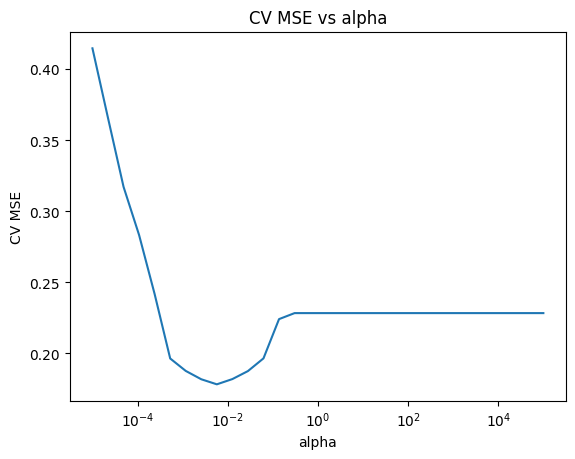

In [17]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("CV MSE vs alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.266300674237673, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 16.844186611830647, tolerance: 0.005874295774647887
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.04334555655642, tolerance: 0.005915492957746482
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

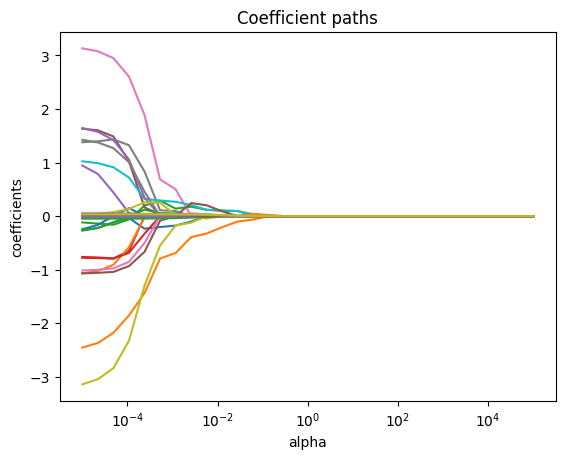

In [18]:
coefs = []

for a in alphas:
    model = LassoCV(alphas=[a], cv=20, max_iter=10000).fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Coefficient paths")
plt.show()

In [19]:
lasso_coefs = lasso.coef_

selected = []
zero_count = 0

for name, coef in zip(feature_names, lasso_coefs):
    if coef != 0:
        selected.append(name)
    else:
        zero_count += 1

print("Selected:", selected[:10])  # just show some
print("Proportion zero:", zero_count / len(lasso_coefs))

Selected: ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'smoking', 'anaemia diabetes', 'diabetes high_blood_pressure']
Proportion zero: 0.5862068965517241


In [20]:
for name, lr_c, lasso_c in zip(feature_names, lr.coef_, lasso_coefs):
    print(name, lr_c, lasso_c)

age 1.5391556093617123 -0.0
ejection_fraction -2.19249366423424 -0.3261238647861613
serum_creatinine -0.8535881544613119 0.11742615461240802
age^2 -3.6786539253257984 0.0
age ejection_fraction -0.600918026980501 -0.0
age serum_creatinine 1.8415625716810304 0.0
ejection_fraction^2 3.43097646455047 0.0
ejection_fraction serum_creatinine 2.6733936217891396 0.0
serum_creatinine^2 -2.6470406100690997 -0.0
age^3 1.993134942297863 0.11621447008946068
age^2 ejection_fraction 0.9080259541106185 0.0
age^2 serum_creatinine -0.6975215091977227 0.0
age ejection_fraction^2 -0.08120632445369474 0.0
age ejection_fraction serum_creatinine -1.5776652636623731 0.0
age serum_creatinine^2 1.2840992885585893 -0.0
ejection_fraction^3 -1.2503410525098886 0.20075017957058341
ejection_fraction^2 serum_creatinine -1.2700431389642268 0.034419438412784976
ejection_fraction serum_creatinine^2 1.1794749306635366 -0.0
serum_creatinine^3 0.07215577717304661 -0.04555791817173447
anaemia 0.004008045230995044 0.013163073

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

The ridge regression objective function is:

$$
\frac{1}{n} \sum_{i=1}^n (y_i^* - b_0 - b_1 x_i^*)^2 + \alpha b_1^2
$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

Because the data is mean-centered, we have:

$$
b_0 = 0
$$

The solution for the slope coefficient is:

$$
b_1 = \frac{\sum x_i^* y_i^*}{\sum (x_i^*)^2 + \alpha}
$$

3. How does increasing $\alpha$ change the slope coefficient?

As $\alpha$ increases, the denominator increases, so $b_1$ decreases in magnitude. This means the slope is shrunk toward zero, making the model less sensitive to changes in $x$.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

With the LASSO penalty, the objective is not differentiable at zero, which makes solving it more difficult using standard derivatives.

LASSO can set coefficients exactly to zero. This happens when:

$$
\left| \sum x_i^* y_i^* \right| \leq \alpha
$$

In this case, the penalty outweighs the relationship between $x$ and $y$, so the model sets $b_1 = 0$.